# **1. 손글씨 도형**
- 손으로 그린 원, 삼각형, X 이미지를 CNN 분류
- 데이터 구성 : 학습 데이터 240장 , 테스트 60 장, 3개의 클래스가 균등하게 구성

In [151]:
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import zipfile
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from pathlib import Path


In [152]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [153]:
extract_dir = Path("./data")# parents=True >> data/shape 상위폴더까지 만들어라
if not extract_dir.exists():
    extract_dir.mkdir(parents=True, exist_ok=True)# exist_ok=True 있으면 넘어가고 없으면 만들어라

In [154]:
with zipfile.ZipFile("./data/shape.zip", "r") as zip_ref:
    zip_ref.extractall("./data")

In [155]:
shape_root = extract_dir / 'shape'
train_dir = shape_root / 'train'
test_dir = shape_root / 'test'
print('학습 경로 : ', train_dir)
print('테스트 경로 : ', test_dir)

학습 경로 :  data\shape\train
테스트 경로 :  data\shape\test


# **2.ImageFolder**
하위 폴더 이름을 클래스 이름으로 사용하며, 알파벳 순서대로 클래스 번호를 지정함
> 라벨이 안되있을때 폴더명을 기준으로 라벨링 해주는 것

In [156]:
# cir(0). tri(1), x(2) 
raw_train = datasets.ImageFolder(train_dir)
raw_test = datasets.ImageFolder(test_dir)

print('클래스 :', raw_train.classes)
print('클래스 번호 :', raw_train.class_to_idx)
print('학습 데이터 이미지 수 : ', len(raw_train))
print('테스트 데이터 이미지 수 : ', len(raw_test))


클래스 : ['cir', 'tri', 'x']
클래스 번호 : {'cir': 0, 'tri': 1, 'x': 2}
학습 데이터 이미지 수 :  240
테스트 데이터 이미지 수 :  60


# **3. 전처리와 데이터 증강**
- 모든 이미지를 28*28 1채널 흑백으로 통일함
- 흰 배경에 검은 선으로 그려진 이미지를 반전하여 선 부분이 큰 값을 갖게 함
- 픽셀 값을 텐서로 바꾼 뒤, 평균 0.5, 표준편차 0.5로 정규화
- 일반화 성능을 높이기 위해 학습 데이터에만 회전/이동/크기 등을 변화를 적용

> 검은바탕에 흰글씨를 더 잘 찾음 검은색이 0 값이라서

In [157]:
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomInvert(p=1.0),#모든 픽셀을 반전
    transforms.RandomAffine(degrees=12, translate=(0.08, 0.08), scale=(0.90, 1.10)),
    # ToTensor() : 텐서형으로 변환, 0~1사이로 정규화
    transforms.ToTensor(),
    # 중앙값을 0, 범위를 -1~1로 조절 데이터가 한쪽으로 치우쳐져 있는 것 보다 종모양으로 중심이 있으며 좌우 대칭으로 펼쳐져있는 형태가 경사하강법에서 효율이 좋아서
    transforms.Normalize(mean=(0.5,), std=(0.5,))#0.5, 튜플로 만든 것 컬러일 때는 여러개(채널별로 계산)  ex) 0.5, 0.5, 0.5
])
# eval_transform = 위에서 증강 기법만 없앰
eval_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomInvert(p=1.0),#모든 픽셀을 반전
    transforms.ToTensor(),
    # 중앙값을 0, 범위를 -1~1로 조절
    transforms.Normalize(mean=(0.5,), std=(0.5,))

])

# **4. 학습/검증/테스트 데이터 분리**
- 학습 데이터 : 가중치를 실제로 업데이트
- 검증 데이터 : 학습 중 모델 선택과 과적합 확인에 사용
- 테스트 데이터 : 모든 학습과 모델 선택이 끝난 뒤, 최종 성능을 확인

In [158]:
base_dataset = datasets.ImageFolder(train_dir)
class_names = base_dataset.classes
num_classes = len(class_names)
num_classes

3

In [159]:
print(base_dataset.targets)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [160]:
np.where(np.array(base_dataset.targets) == 0)[0]# 참인 경우만 가져온다

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79])

In [161]:
train_indices = []
val_indices = []
rng = np.random.default_rng(SEED)

for class_idx in range(num_classes):
    indices = np.where(np.array(base_dataset.targets) == class_idx )[0]
    rng.shuffle(indices)
    split = int(len(indices)*0.8)
    train_indices.extend(indices[:split].tolist())
    val_indices.extend(indices[split:].tolist())

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full = datasets.ImageFolder(train_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)


#기존 데이터셋에서 원하는 데이터만 선택하여 새로운 데이터셋을 생성
train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

print('학습 : ', len(train_dataset))
print('검증 : ', len(val_dataset))
print('테스트 : ', len(test_dataset))

학습 :  192
검증 :  48
테스트 :  60


In [162]:
BATCH_SIZE = 32

# pin_memory = True
# CPU의 일반적인 메모리를 Pageable Memory라고 하고, GPU 전송에 유리하도록 고정된 CPU 메모리를 Pinned Memory라고 함

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

# **5. 이미지와 텐서 모양 확인**

- CNN 입력 텐서: [배치, 채널, 높이, 너비]
- 현재 데이터의 배치 shape: [32, 1, 28, 28]

In [163]:
images, labels =next(iter(train_loader))
print('이미지 배치: ', images.shape)
print('레이블 배치: ', labels.shape)


이미지 배치:  torch.Size([32, 1, 28, 28])
레이블 배치:  torch.Size([32])


In [164]:
def denormalize(image):
    return image * 0.5 + 0.5

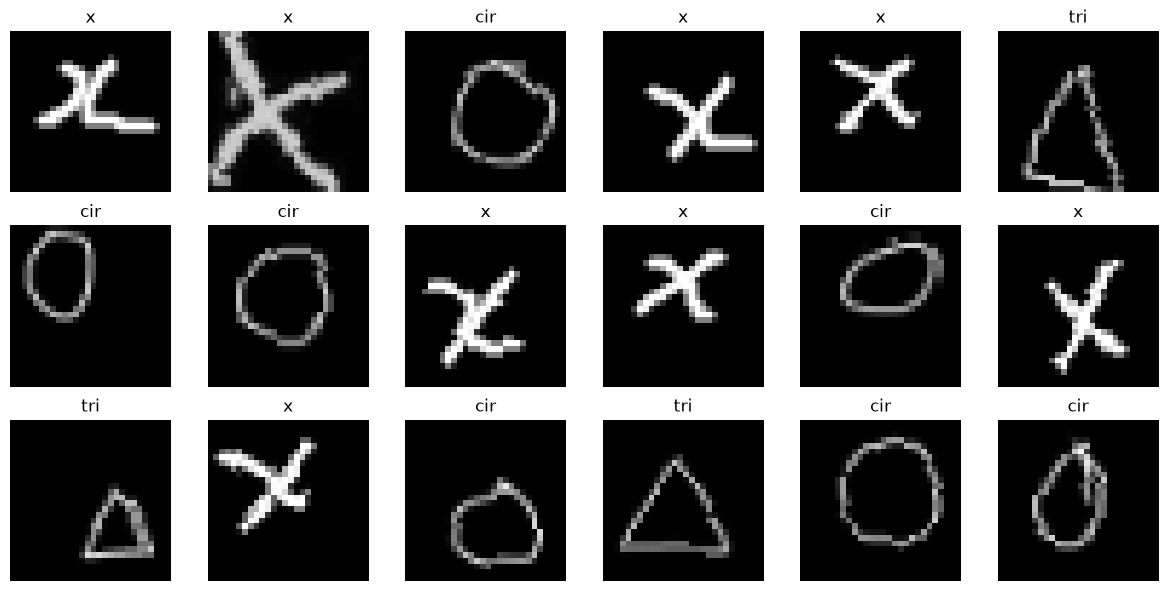

In [165]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for ax, image, label in zip(axes.flat, images[:18], labels[:18]):
    ax.imshow(denormalize(image).squeeze(0), cmap='gray', vmin=0, vmax=1)
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

# **6. CNN 모델**

### BatchNorm2d
CNN이 학습하면서 만들어낸 각 채널(feature map)의 값들을 적절한 범위로 정규화해서 학습을 더 안정적으로 만들어주는 층

```
입력 이미지 > Conv2d > 32개의 Feature Map 생성 > BatchNorm2d > 각 Feature Map의 값들을 정규화 > ReLU
nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
nn.BatchNorm2d(32),
nn.ReLU()
```

> CNN의 Conv2d를 통과하면 값들이 여러가지로 변함. 처음 입력 이미지가 어느 정도 정규화되어 있어도 Conv2d를 통과하고 나면 가중치와 계산되면서 채널마다 값의 분포가 달라질 수 있음. BatchNorm은 값을 어느 정도 정돈해서 다음 층으로 보내주는 역할을 함

### AdaptiveAvgPool2d
- 입력 이미지의 크기가 얼마이든 상관없이 최종 출력 크기를 항상 측정 크기로 만들어주는 평균 풀링 레이어
- CNN에서 분류 모델의 마지막 부분에 자주 사용

```
nn.AvgPool2d(kernel_size=2)

1 3 2 4
5 7 6 8
2 4 1 3
6 8 5 7

2*2의 평균을 계산 > (1+3+5+7)/4 = 4

nn.AdaptiveAvgPool2d((1,1))
입력 크기가 어떻게 생겼든 최종적으로 1*1로 만들어줘!

1 2
3 4

(1+2+3+4)/4  = 2.5
Faeture Map 하나를 대표하는 값 하나가 만들어짐

```

```
예) Conv2d를 통과해서 Faeture Map이 64개일 경우
[32, 64, 14, 14]
nn.AdaptiveAvgPool2d((1,1))
[32, 64 , 1, 1]

채널 개수는 그대로 유지되고 H,W만 줄어듬
```

### Dropout
- 신경망이 학습할 때 일부 뉴런을 일부러 랜덤하게 꺼버리는 기법
- 과적합을 줄이기 위해 사용
- 네트워크에서 뉴런을 영구적으로 삭제하는 것이 아니며, 학습 순간에만 뉴런의 출력을 0으로 함
- model.train()시 Dropout 작동, model.eval() Dropout 꺼짐


In [166]:
# 통과하는 층마다 , 가 있어야함
# BatchNorm2d(32) 가중치가 있음 정도만 기억
class ShapeCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),# 기본값 False, 새로운 메모리에 따로 저장 x 기존 텐서값을 그자리에서 즉시 변경(데이터를 덮어쓴다 : 메모리 절약)
        nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(32),
        # BatchNorm에서 넘어온 Tensor 를 별도의 새로운 Tensor로 복사해서 처리하지 말고, Tensor의 메모리를 직접 수정하여 메모리를 절약
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2),

    
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(64, num_classes)
            
        )

    def forward(self, x):
        x= self.features(x)
        return self.classifier(x)


In [167]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')

elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')

elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')

else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [168]:
model = ShapeCNN(num_classes=num_classes).to(DEVICE)
model

ShapeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2

In [169]:
criterion = nn.CrossEntropyLoss()

### AdamW
- Adam에 가중치 감쇠(Weight Decay)를 적용한 방식
- 딥런이 모델의 가중치가 지나치게 커지면 학습 데이터에 너무 맞춰지는 과적합이 발생할 수 있음 > Weight Decay로 학습 중에 가중치를 조금씩 줄여서 너무 커지지 않도록 하는 방법을 사용
- 과적합을 줄이고 일반화 성능을 높이도록 만듦

```
Gradient >  Adam의 적용적 계산 > 가중치 업데이트 > Weight Decay를 적용

```

- Adam - 학습률을 파라미터마다 자동으로 조절하면서, Momentum + RMSProp의 장점을 결합한 옵티마이저. 일반적으로 빠르고 안정적으로 학습되어 딥러닝에서 많이 사용됨.
- Optimizer(옵티마이저) - 손실 함수(Loss)를 줄이기 위해 가중치와 편향을 어떤 방식으로 업데이트할지 결정하는 알고리즘. 대표적으로 SGD, Adam 등이 있음.
- SGD (Stochastic Gradient Descent) - 손실 함수의 기울기(Gradient)를 계산한 뒤 그 반대 방향으로 가중치를 조금씩 이동시키는 방식. 구조가 단순하고 일반화 성능이 좋은 편이지만, Adam보다 학습이 느리거나 학습률 설정에 민감할 수 있음.

- 규제(Regularization): 모델이 학습 데이터에 너무 과적합되지 않도록 제한을 거는 방법. 대표적으로 L1, L2 규제, Dropout, Weight Decay 등이 있음.
- AdamW: Adam 옵티마이저에 Weight Decay를 올바른 방식으로 분리해서 적용한 옵티마이저. 즉, Adam의 빠른 학습 장점 + 가중치가 너무 커지는 것을 억제하는 효과를 같이 가짐.

In [170]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

### Scheduler
- 검증 성능이 더 이상 좋아지지 않을 때 자동으로 학습률을 낮춰주는 기능
- 새로운 가중치 = 기존 가중치 - 학습률 * 기울기

```
Epoch1 Loss : 0.8
Epoch2 Loss : 0.6
Epoch3 Loss : 0.5
Epoch4 Loss : 0.43
Epoch5 Loss : 0.40 # 이후로 Loss가 좋아지지 않음
Epoch6 Loss : 0.41
Epoch7 Loss : 0.42
Epoch8 Loss : 0.41


```

- Epoch(에포크)는 전체 학습 데이터를 한 번 전부 학습한 횟수입니다.
- mode : 무엇을 기준으로 좋아졌다고 판단할지를 결정
- factor : 학습률을 반영하는 값
- patience : 몇 번까지 참아줄 것인지 설정

In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)
# ReduceLROnPlateau 개선되지 않으면 학습률 개선

### 학습과 평가 함수

In [172]:
def run_epoch(model, loader, criterion, device, optimizer=None):

    is_training = optimizer is not None

    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    

    context = torch.enable_grad() if is_training else torch.inference_mode()
    
    with context:
        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # 학습할 때만 기울기 초기화
            if is_training:
                optimizer.zero_grad(set_to_none=True)

            # 학습/검증 둘 다 실행해야 함
            logits = model(images)
            loss = criterion(logits, labels)

            # 학습할 때만 역전파 + 가중치 수정
            if is_training:
                loss.backward()
                optimizer.step()

            # 학습/검증 둘 다 계산해야 함
            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()

            total_samples += batch_size

    return (
        total_loss / total_samples,
        total_correct / total_samples
    )

### 모델 학습과 Early Stopping
- 검증 손실이 가장 낮을 때의 가중치를 저장
- 일정 횟수 동안 검증 손실이 개선되지 않으면 학습을 조기에 종료하여 과적합과 불필요한 학습을 줄임

In [173]:
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8
best_val_loss = float('inf')#inf 인피니티 무한대, 로스값이 작아지는 값을 찾아야하기 때문에 큰값을 넣어두는것 왜냐하면 인피니티를 주면 무조건 인피니티 보다는 처음에 작을 것이기 때문
wait = 0
history = {"train_loss":[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_model_path ='best_shape_cnn.pth'

In [174]:
images, labels = next(iter(train_loader))

print("images shape :", images.shape)
print("labels shape :", labels.shape)
print("labels :", labels)

images shape : torch.Size([32, 1, 28, 28])
labels shape : torch.Size([32])
labels : tensor([2, 2, 1, 2, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 2, 2, 0, 0, 2, 2, 0, 1, 2,
        1, 2, 1, 1, 1, 0, 0, 2])


In [175]:
for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, DEVICE, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'train loss {train_loss:.4f}, acc {train_acc*100:6.2f}% | '
        f'val loss {val_loss:.4f}, acc {val_acc*100:6.2f}% | '
        f'lr {current_lr:.6f}'
    )

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= EARLY_STOPPING_PATIENCE:
            print('검증 손실이 더 이상 개선되지 않아 학습을 종료합니다.')
            break

Epoch 01/50 | train loss 0.7838, acc  60.94% | val loss 1.0538, acc  35.42% | lr 0.001000
Epoch 02/50 | train loss 0.5668, acc  70.31% | val loss 0.8642, acc  64.58% | lr 0.001000
Epoch 03/50 | train loss 0.5821, acc  67.71% | val loss 0.7336, acc  66.67% | lr 0.001000
Epoch 04/50 | train loss 0.4857, acc  79.69% | val loss 0.6678, acc  66.67% | lr 0.001000
Epoch 05/50 | train loss 0.4549, acc  80.73% | val loss 0.6635, acc  66.67% | lr 0.001000
Epoch 06/50 | train loss 0.4311, acc  82.81% | val loss 0.5494, acc  66.67% | lr 0.001000
Epoch 07/50 | train loss 0.4233, acc  83.33% | val loss 0.5036, acc  66.67% | lr 0.001000
Epoch 08/50 | train loss 0.3644, acc  85.94% | val loss 0.3781, acc  89.58% | lr 0.001000
Epoch 09/50 | train loss 0.3391, acc  86.98% | val loss 0.3852, acc  81.25% | lr 0.001000
Epoch 10/50 | train loss 0.2820, acc  90.62% | val loss 0.3941, acc  83.33% | lr 0.001000
Epoch 11/50 | train loss 0.2594, acc  91.15% | val loss 0.3352, acc  81.25% | lr 0.001000
Epoch 12/5

# **7.학습 곡선으로 과적합 확인**
- 학습 손실과 검증 손실이 함께 감소하면 정상적인 학습에 가까움
- 학습 손실은 게속 감소하지만, 검증 손실이 증가하면 과적합 가능성이 큼
- 학습/검증 정확도가 모두 낮으면 모델 용량, 전처리, 학습률, 데이터 품질 등을 점검해야 함

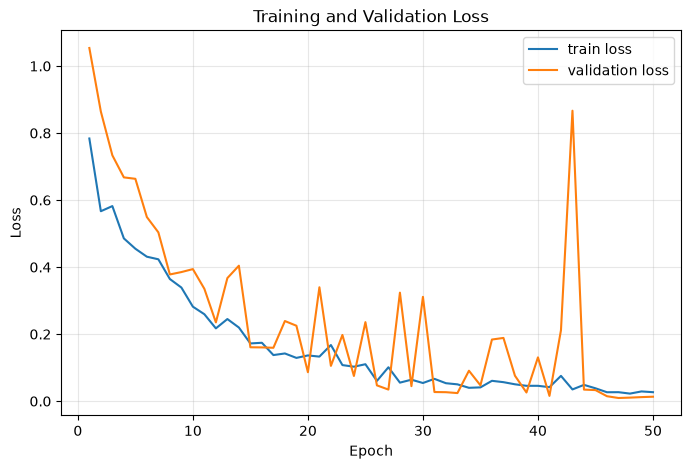

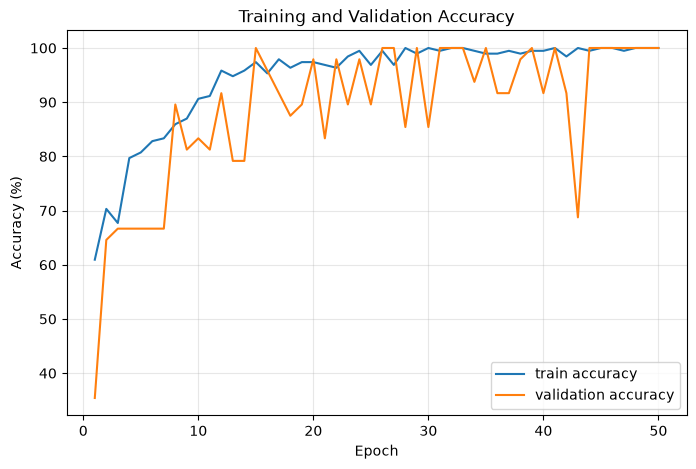

In [176]:
epochs_ran = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history['train_loss'], label='train loss')
plt.plot(epochs_ran, history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, np.array(history['train_acc']) * 100, label='train accuracy')
plt.plot(epochs_ran, np.array(history['val_acc']) * 100, label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **8.학습된 모델로 테스트 평가**

### 학습되지 않은 모델로 테스트 평가

In [177]:
model = ShapeCNN(num_classes).to(DEVICE)
model

ShapeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2

In [178]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, DEVICE)
print(f'테스트 Loss: {test_loss:.4f}')
print(f'테스트 acc : {test_acc *100:.2f}')

테스트 Loss: 1.1005
테스트 acc : 33.33


### 가중치를 불러와 모델에 적용한 후 테스트 평가

In [179]:
model = ShapeCNN(num_classes).to(DEVICE)
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))

<All keys matched successfully>

In [180]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, DEVICE)
print(f'테스트 Loss: {test_loss:.4f}')
print(f'테스트 acc : {test_acc *100:.2f}')

테스트 Loss: 0.0792
테스트 acc : 96.67


# **9. 혼동행렬과 클래스별 성능**
- 전체 정확도가 높아도 특정 클래스만 자주 틀릴 수 있음
- 혼동행렬은 실제 클래스와 예측 클래스의 조합을 볼 수 있음
- 대각선 값이 클수록 올바르게 분류한 이미지가 많다는 뜻

In [181]:
def collect_predictions(model, loader):
    model.eval()
    all_images = []
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.inference_mode():
        for images, labels in loader:
            logits = model(images.to(DEVICE))
            probs = torch.softmax(logits, dim=1).cpu()
            preds = probs.argmax(dim=1)

            all_images.append(images.cpu())
            all_labels.append(labels.cpu())
            all_preds.append(preds)
            all_probs.append(probs)

    return (
        torch.cat(all_images),
        torch.cat(all_labels),
        torch.cat(all_preds),
        torch.cat(all_probs),
    )

In [182]:
test_images, y_true, y_pred, y_prob = collect_predictions(model, test_loader)

In [183]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

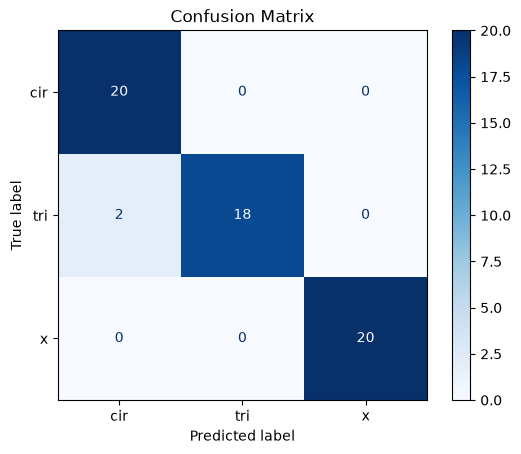

              precision    recall  f1-score   support

         cir     0.9091    1.0000    0.9524        20
         tri     1.0000    0.9000    0.9474        20
           x     1.0000    1.0000    1.0000        20

    accuracy                         0.9667        60
   macro avg     0.9697    0.9667    0.9666        60
weighted avg     0.9697    0.9667    0.9666        60



In [184]:
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    y_true.numpy(),
    y_pred.numpy(),
    target_names=class_names,
    digits=4,
    zero_division=0,
))

# **10. 오분류 이미지 분석**
- 모델이 틀린 이미지에는 데이터 품질, 모호한 이미지, 전처리 문제, 부족한 학습 데이터 등 중요한 단서가 들어가 있음
- 단순히 정확도만 보는 것보다 오분류 사례를 직접 확인하는 것이 모델 개선에 매우 중요

In [185]:
wrong_indices = torch.where(y_true != y_pred)[0]
print('오분류 이미지 수:', len(wrong_indices))

오분류 이미지 수: 2


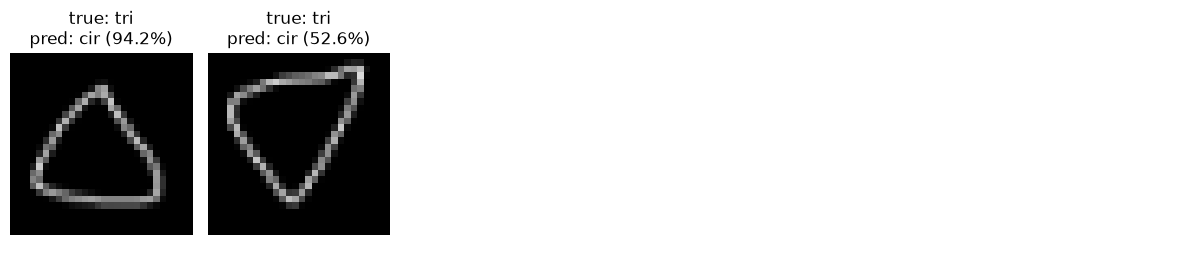

In [187]:
if len(wrong_indices) == 0:
    print('현재 테스트 데이터에서 오분류 이미지가 없습니다.')
else:
    show_count = min(18, len(wrong_indices))
    selected = wrong_indices[:show_count]
    rows = int(np.ceil(show_count / 6))
    fig, axes = plt.subplots(rows, 6, figsize=(12, 2.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis('off')

    for ax, idx in zip(axes, selected):
        true_idx = y_true[idx].item()
        pred_idx = y_pred[idx].item()
        confidence = y_prob[idx, pred_idx].item() * 100
        ax.imshow(denormalize(test_images[idx]).squeeze(0), cmap='gray', vmin=0, vmax=1)
        ax.set_title(
            f'true: {class_names[true_idx]}\n'
            f'pred: {class_names[pred_idx]} ({confidence:.1f}%)'
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### 성능을 더 높일 때 점검할 순서

1. 잘못된 레이블이나 지나치게 모호한 그림이 없는지 확인
2. 실제 사용 환경과 학습 데이터의 배경색/선 굵기/크기 차이를 줄임
3. 클래스별 데이터를 더 다양하게 수집
4. 증강 강도를 조금씩 바꿔 검증 성능을 비교
5. 데이터가 충분히 늘어난 뒤 모델 크기와 학습률을 조절

> 이 데이터는 전체 300장으로 매우 작음. 테스트 정확도가 높더라도 실제 손글씨 전체를 대표한다고 단정할 수 없음. 새로운 사람이 그린 별도의 데이터도 추가 검증해야 함